# Scoring a phase picker: every metric, on every benchmark we ran

Two audiences, one page.

**If you pick phases for a living**, this is the full metric set for the five
QuakeScope benchmarks, computed from the picks each study exported, with the
threshold treatments reported side by side because they disagree.

**If you build software or agents and want to know how earth scientists judge a
model**, read section 1 first. The short version: our ground truth is a
by-product of somebody else's job, not a labelled test set, and almost every
methodological choice below follows from that one fact. A metric that is
standard in machine learning (precision, F1, a confusion matrix) is either not
identifiable here or means something weaker, and saying which is which is the
work.

Metric definitions live in
[`sb_catalog/src/benchmark_metrics.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/sb_catalog/src/benchmark_metrics.py)
and are pinned by
[`tests/test_benchmark_metrics.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/tests/test_benchmark_metrics.py).
Nothing on this page is typed in: every number is computed here from
`docs/benchmark/results/`, which the benchmark notebooks write when they run.

**To compute all of this on your own picks**, skip to section 8: there is one
script, it takes two CSV files, and section 8 checks that it reproduces this
page exactly.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from sb_catalog.src.benchmark_metrics import (WITHIN, best_threshold, detection_scores, ece,
                                              match_picks, multiplicity, phase_confusion,
                                              recall_at_budget, reliability, residual_stats, sweep)

RES = Path("../docs/benchmark/results")
WEIGHTS = ["quakescope2026", "jma_wc", "original", "instance"]
COLORS = dict(zip(WEIGHTS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
SHARED_THR = 0.3          # the threshold everyone reads a picker at
DETECT_TOL = 0.5          # s, an analyst pick counts as recovered within this
RESIDUAL_TOL = 2.0        # s, wide enough not to truncate the residual distribution
SWEEP = np.round(np.arange(0.02, 0.96, 0.02), 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linewidth": 0.5, "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False})

def load(study, name):
    p = RES / study / f"{name}.csv"
    return pd.read_csv(p, parse_dates=[c for c in ("time",) if c in pd.read_csv(p, nrows=0).columns]) if p.exists() else None

studies = {}
for study in ("us_sequences", "global_sequences"):
    picks, ref = load(study, "model_picks"), load(study, "reference_picks")
    if picks is None or ref is None:
        print(f"{study}: no raw picks exported yet"); continue
    studies[study] = (picks, ref)
    print(f"{study}: {len(picks):,} model picks, {len(ref):,} reference arrivals, "
          f"{picks.sequence.nunique()} sequences, {picks.weights.nunique()} weight sets")
meta = {s: json.loads((RES / s / "meta.json").read_text()) for s in
        [d.name for d in RES.iterdir() if (d / "meta.json").exists()]}
print("\nstudies with results:", ", ".join(sorted(meta)))

us_sequences: 41,579 model picks, 1,064 reference arrivals, 5 sequences, 4 weight sets
global_sequences: 79,026 model picks, 2,898 reference arrivals, 3 sequences, 4 weight sets

studies with results: global_sequences, obs_offshore, ridgecrest_aftershocks, us_sequences, western_reproduction


## 1. Why the usual metrics do not transfer unchanged

A machine-learning benchmark has a labelled test set: for every window, every
arrival is known. Then a model pick either matches a label (true positive) or
does not (false positive), a label with no pick is a false negative, and
precision, recall, F1 and a confusion matrix all follow.

**We do not have that.** Our reference is the arrival list attached to
earthquakes an operator located. An analyst picked what the location needed and
stopped: in an aftershock sequence with fifty events an hour, most arrivals are
never marked. So:

| quantity | on a labelled set | on an operator bulletin |
|---|---|---|
| recall | true | **true** — every reference arrival either has a model pick nearby or does not |
| precision | true | **lower bound** — an unmatched model pick may be a false positive or a real arrival nobody marked |
| F1, MCC | true | **lower bound**, inheriting precision's |
| phase swap (P vs S) | true | **true** — both sides carry a phase label |
| onset residual | true | **true**, but truncated by the matching tolerance (section 3) |
| calibration | true | **lower bound**, inheriting precision's |
| duplicate picks | true | **true** |

Everything below that depends on a false-positive count is named `_lb` and is
comparable *between models on the same reference*, which is what choosing a
model needs. It is not comparable with an F1 from a labelled-dataset paper.
This is the single most common error we see in applied picker comparisons: an
F1 computed against a bulletin, reported as if it were an F1 against labels.

**A second trap: the threshold is not the operating point.** Each model's
confidence sits on its own scale. At a shared 0.3 one model emits twice the
picks of another and collects both more recall and more extra detections.
Comparing at a fixed threshold measures how liberal a model is as much as how
good it is, so we report three treatments together: the shared threshold, the
matched pick budget, and each model's own best threshold.

## 2. Detection, all three threshold treatments

In [2]:
def curves_for(picks, ref, sequence, phase):
    # A threshold sweep per weight set, from the one inference run.
    r = sorted(ref[(ref.sequence == sequence) & (ref.phase == phase)].time.astype("int64") / 1e9)
    out = {}
    for name, g in picks[(picks.sequence == sequence) & (picks.phase == phase)].groupby("weights"):
        # Matching is per station: a pick only answers for its own station.
        rows = []
        for thr in SWEEP:
            keep = g[g.conf >= thr]
            tp = extra = 0
            for sta, gs in keep.groupby("station"):
                rr = sorted(ref[(ref.sequence == sequence) & (ref.phase == phase)
                                & (ref.station == sta)].time.astype("int64") / 1e9)
                m = match_picks(rr, sorted(gs.time.astype("int64") / 1e9), tol=DETECT_TOL)
                tp += len(m["pairs"]); extra += len(m["extra"])
            rows.append({"threshold": float(thr), "emitted": len(keep),
                         **detection_scores(len(r), tp, extra)})
        out[name] = pd.DataFrame(rows)
    return out

ALL = {}
for study, (picks, ref) in studies.items():
    for sequence in picks.sequence.unique():
        for phase in ("P", "S"):
            ALL[(study, sequence, phase)] = curves_for(picks, ref, sequence, phase)
print(f"swept {len(ALL)} (sequence, phase) combinations x {len(WEIGHTS)} weight sets "
      f"x {len(SWEEP)} thresholds, all from stored picks")

swept 16 (sequence, phase) combinations x 4 weight sets x 47 thresholds, all from stored picks


In [3]:
rows = []
for (study, sequence, phase), curves in ALL.items():
    budget = recall_at_budget(curves, n_points=1)
    for name, c in curves.items():
        at = c.iloc[(c.threshold - SHARED_THR).abs().argmin()]
        b = best_threshold(c, by="f1_lb")
        rows.append(dict(
            study=study.replace("_sequences", ""), sequence=sequence, phase=phase, weights=name,
            n_ref=int(at.n_reference),
            recall_at_03=at.recall, precision_lb_at_03=at.precision_lb, f1_lb_at_03=at.f1_lb,
            emitted_at_03=int(at.emitted), extra_rate_at_03=at.extra_rate,
            recall_at_budget=budget[name].iloc[0] if name in budget else np.nan,
            budget=int(budget.budget.iloc[0]) if budget.budget.notna().iloc[0] else np.nan,
            best_thr=b.get("best_threshold"), f1_lb_at_best=b.get("best_f1_lb"),
            recall_at_best=b.get("recall_at_best")))
detection = pd.DataFrame(rows)
detection.to_csv(RES / "detection_full.csv", index=False)
print(f"{len(detection)} rows -> docs/benchmark/results/detection_full.csv")
detection.round(3).head(12)

64 rows -> docs/benchmark/results/detection_full.csv


,study,sequence,phase,weights,n_ref,recall_at_03,precision_lb_at_03,f1_lb_at_03,emitted_at_03,extra_rate_at_03,recall_at_budget,budget,best_thr,f1_lb_at_best,recall_at_best
0,us,Ridgecrest,P,instance,347,0.216,0.750,0.336,100,0.072,0.359,208,0.02,0.502,0.467
1,us,Ridgecrest,P,jma_wc,347,0.582,0.598,0.590,338,0.392,0.410,208,0.28,0.595,0.597
2,us,Ridgecrest,P,original,347,0.648,0.459,0.538,490,0.764,0.393,208,0.54,0.556,0.550
3,us,Ridgecrest,P,quakescope2026,347,0.605,0.597,0.601,352,0.409,0.422,208,0.22,0.611,0.663
4,us,Ridgecrest,S,instance,298,0.181,0.551,0.273,98,0.148,0.270,136,0.02,0.474,0.433
5,us,Ridgecrest,S,jma_wc,298,0.487,0.520,0.503,279,0.450,0.284,136,0.18,0.539,0.601
6,us,Ridgecrest,S,original,298,0.725,0.415,0.528,520,1.020,0.264,136,0.44,0.532,0.641
7,us,Ridgecrest,S,quakescope2026,298,0.517,0.529,0.523,291,0.460,0.294,136,0.20,0.554,0.614
8,us,San Simeon,P,instance,62,0.887,0.185,0.306,298,3.919,0.903,434,0.82,0.490,0.581
9,us,San Simeon,P,jma_wc,62,0.855,0.087,0.158,609,8.968,0.839,434,0.76,0.318,0.548


### The three treatments, side by side

One row per sequence and phase: how each weight set ranks depends on which
column you read. `Δ` is the best weight minus the worst on that row.

In [4]:
def rank_table(phase):
    sub = detection[detection.phase == phase]
    out = []
    for (st, seq), g in sub.groupby(["study", "sequence"], sort=False):
        row = {"sequence": f"{seq}"}
        for col, label in (("recall_at_03", "shared 0.3"), ("recall_at_budget", "matched budget"),
                           ("recall_at_best", "own best thr")):
            w = g.set_index("weights")[col].dropna()
            if w.empty:
                row[label] = "-"; continue
            row[label] = f"{w.idxmax()} ({w.max():.2f}, Δ{w.max() - w.min():+.2f})"
        out.append(row)
    return pd.DataFrame(out).set_index("sequence")

for phase in ("P", "S"):
    print(f"\nBest weight set for {phase}, by treatment")
    print(rank_table(phase).to_string())


Best weight set for P, by treatment
                             shared 0.3                 matched budget                   own best thr
sequence                                                                                             
Ridgecrest      original (0.65, Δ+0.43)  quakescope2026 (0.42, Δ+0.06)  quakescope2026 (0.66, Δ+0.20)
San Simeon      instance (0.89, Δ+0.06)        instance (0.90, Δ+0.06)  quakescope2026 (0.71, Δ+0.16)
Monte Cristo    instance (0.88, Δ+0.12)        instance (0.88, Δ+0.12)          jma_wc (0.75, Δ+0.19)
Mendocino 2024    jma_wc (0.90, Δ+0.22)        instance (0.89, Δ+0.20)  quakescope2026 (0.76, Δ+0.21)
Monroe WA                             -                              -                              -
Kaikoura 2016     jma_wc (0.70, Δ+0.06)        instance (0.69, Δ+0.13)        original (0.58, Δ+0.12)
Norcia 2016       jma_wc (0.79, Δ+0.18)        instance (0.77, Δ+0.16)        instance (0.70, Δ+0.10)
Thessaly 2021     jma_wc (0.75, Δ+0.03)      

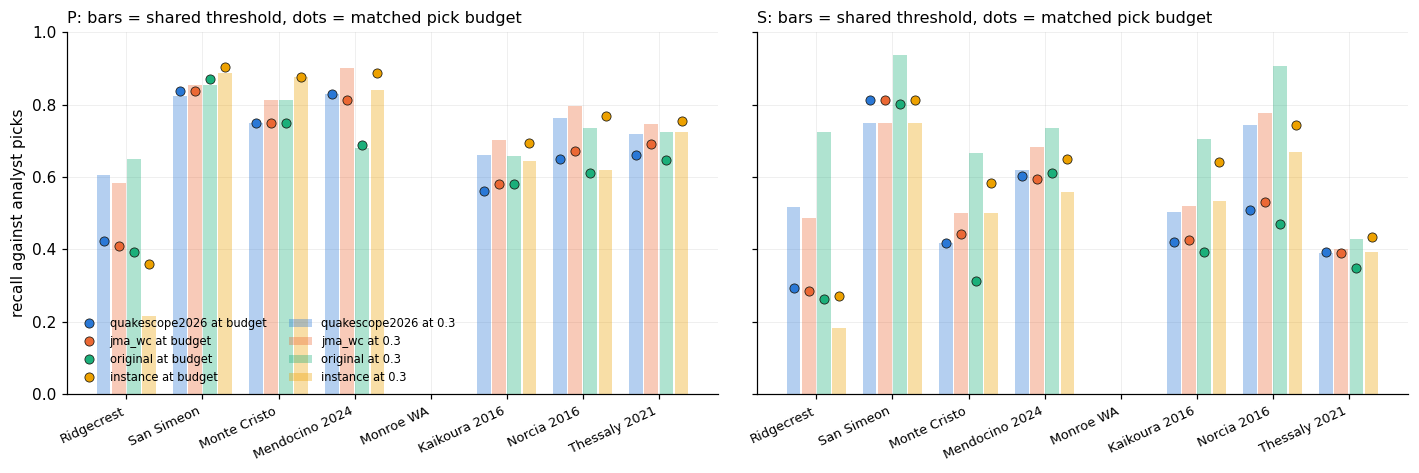

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, phase in zip(axes, ("P", "S")):
    sub = detection[detection.phase == phase]
    seqs = list(dict.fromkeys(sub.sequence))
    w = 0.8 / len(WEIGHTS)
    for i, name in enumerate(WEIGHTS):
        xs, y03, ybud = [], [], []
        for j, s in enumerate(seqs):
            r = sub[(sub.sequence == s) & (sub.weights == name)]
            if not len(r):
                continue
            xs.append(j + (i - 1.5) * w)
            y03.append(float(r.recall_at_03.iloc[0])); ybud.append(float(r.recall_at_budget.iloc[0]))
        ax.bar(xs, y03, width=w * 0.9, color=COLORS[name], alpha=0.35,
               label=f"{name} at 0.3" if phase == "P" else None)
        ax.plot(xs, ybud, "o", ms=6, color=COLORS[name], mec="#16150f", mew=0.5,
                label=f"{name} at budget" if phase == "P" else None)
    ax.set_xticks(range(len(seqs))); ax.set_xticklabels(seqs, rotation=25, ha="right", fontsize=8.5)
    ax.set_title(f"{phase}: bars = shared threshold, dots = matched pick budget", loc="left", fontsize=10.5)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("recall against analyst picks")
axes[0].legend(frameon=False, fontsize=7.5, ncol=2, loc="lower left")
fig.tight_layout()

The gap between a bar and its dot is what a shared threshold hides. Where the
bars rank the weights differently from the dots, the shared-threshold ranking
is an artefact of calibration, not a statement about picking.

## 3. Onset time, and why the matching tolerance has to be wide

A residual is the model pick minus the analyst pick. If you match at 0.5 s then
no residual can exceed 0.5 s, and any "outlier rate" you compute is a fact
about your tolerance. So detection is scored at 0.5 s and residuals at 2 s,
with `gross_error_rate` reporting the fraction that falls outside 0.5 s. That
is the honest form of the high-residual fraction in Münchmeyer et al. (2022).

MAE and RMSE are both reported because one is insensitive to outliers and the
other is not; MedianAE because it is robust; the median residual because it
separates a systematic early or late pick from scatter.

In [6]:
rows = []
for study, (picks, ref) in studies.items():
    for sequence in picks.sequence.unique():
        for phase in ("P", "S"):
            rsub = ref[(ref.sequence == sequence) & (ref.phase == phase)]
            for name, g in picks[(picks.sequence == sequence) & (picks.phase == phase)
                                 & (picks.conf >= SHARED_THR)].groupby("weights"):
                res, conf, hit = [], [], []
                for sta, gs in g.groupby("station"):
                    rr = sorted(rsub[rsub.station == sta].time.astype("int64") / 1e9)
                    tt = sorted(gs.time.astype("int64") / 1e9)
                    cc = list(gs.sort_values("time").conf)
                    wide = match_picks(rr, tt, cc, tol=RESIDUAL_TOL)
                    res += [p[2] for p in wide["pairs"]]
                    strict = match_picks(rr, tt, cc, tol=DETECT_TOL)
                    h = np.zeros(len(tt), dtype=bool)
                    for _, j, _, _ in strict["pairs"]:
                        h[j] = True
                    conf += cc; hit += list(h)
                st = residual_stats(res, strict_tol=DETECT_TOL)
                rows.append(dict(study=study.replace("_sequences", ""), sequence=sequence,
                                 phase=phase, weights=name,
                                 **{k: v for k, v in st.items()},
                                 ece_lb=ece(conf, hit) if conf else np.nan))
timing = pd.DataFrame(rows)
timing.to_csv(RES / "timing_full.csv", index=False)
cols = ["n", "mae", "rmse", "medae", "bias", "std", "gross_error_rate"] + [f"within_{w:g}" for w in WITHIN]
print("Onset-time statistics at the shared threshold, residuals matched at 2 s")
print(timing.set_index(["phase", "sequence", "weights"])[cols].round(3).to_string())

Onset-time statistics at the shared threshold, residuals matched at 2 s
                                       n    mae   rmse  medae   bias    std  gross_error_rate  within_0.1  within_0.25  within_0.5
phase sequence       weights                                                                                                      
P     Ridgecrest     instance         79  0.103  0.267  0.032 -0.012  0.268             0.051       0.861        0.924       0.949
                     jma_wc          217  0.107  0.311  0.022 -0.002  0.312             0.069       0.889        0.926       0.931
                     original        245  0.148  0.358  0.038  0.028  0.357             0.082       0.792        0.894       0.918
                     quakescope2026  221  0.098  0.289  0.028 -0.002  0.289             0.050       0.878        0.946       0.950
S     Ridgecrest     instance         60  0.164  0.334  0.062 -0.037  0.336             0.100       0.717        0.850       0.900
           

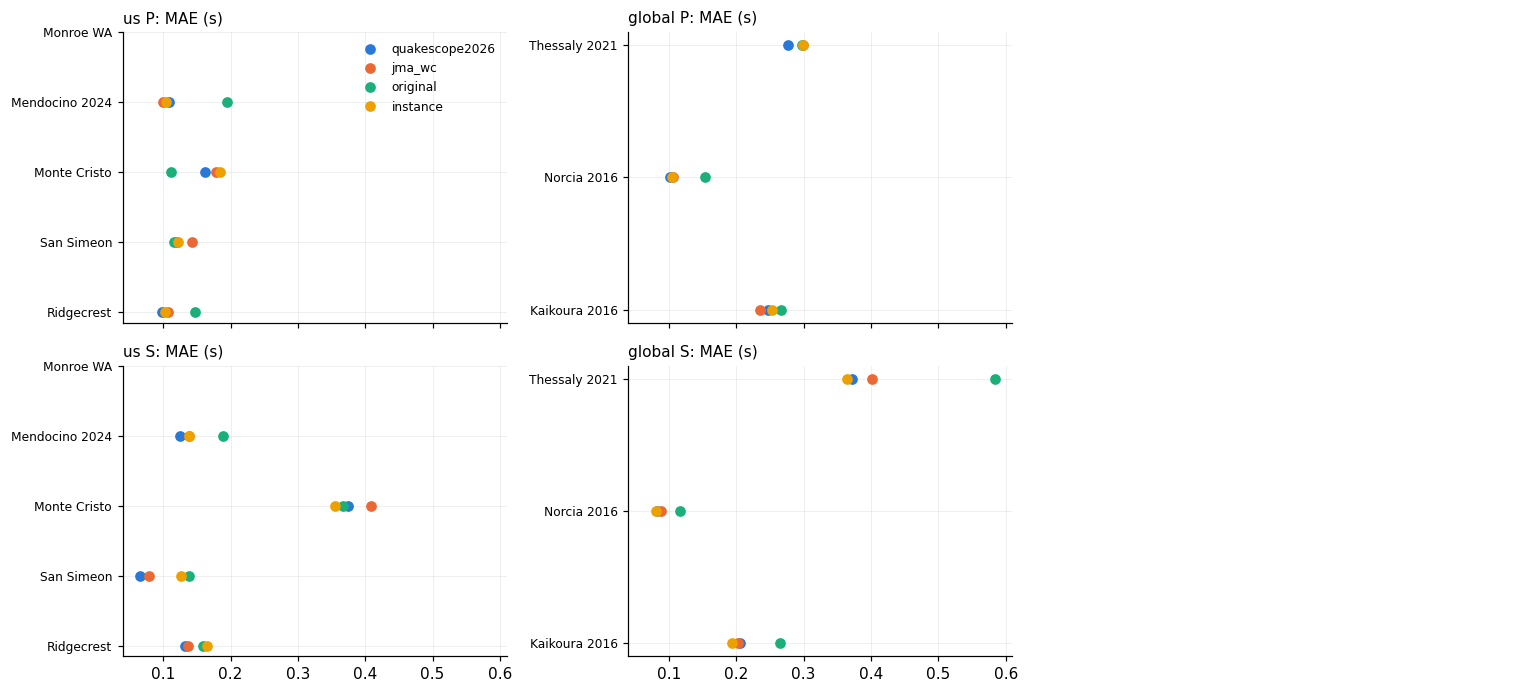

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4), sharex=True)
for row, phase in enumerate(("P", "S")):
    for ax, (study, (picks, ref)) in zip(axes[row], studies.items()):
        for name in WEIGHTS:
            sub = timing[(timing.study == study.replace("_sequences", "")) & (timing.phase == phase)
                         & (timing.weights == name)]
            if sub.empty:
                continue
            ax.errorbar(sub.mae, range(len(sub)), xerr=None, fmt="o", ms=6, color=COLORS[name],
                        label=name if row == 0 and ax is axes[row][0] else None)
        ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.sequence, fontsize=8)
        ax.set_title(f"{study.replace('_sequences','')} {phase}: MAE (s)", loc="left", fontsize=10)
    if len(studies) < 3:
        axes[row][-1].axis("off")
axes[0][0].legend(frameon=False, fontsize=8)
fig.tight_layout()

## 4. Is the confidence a probability? (calibration)

Every downstream user thresholds on `conf`, so whether 0.7 means "70 % likely a
real arrival" is a practical question, not a curiosity. It is also the
mechanism behind section 2: if two models are calibrated differently, one
threshold puts them at different operating points.

Read as a lower bound, for the same reason precision is: a pick that matches
nothing may still be a real arrival.

 study        weights  ece_lb     n
    us quakescope2026   0.152 11736
    us         jma_wc   0.176 13589
    us       original   0.248 10777
    us       instance   0.174  5477
global quakescope2026   0.152 22589
global         jma_wc   0.165 22732
global       original   0.254 23025
global       instance   0.089 10680


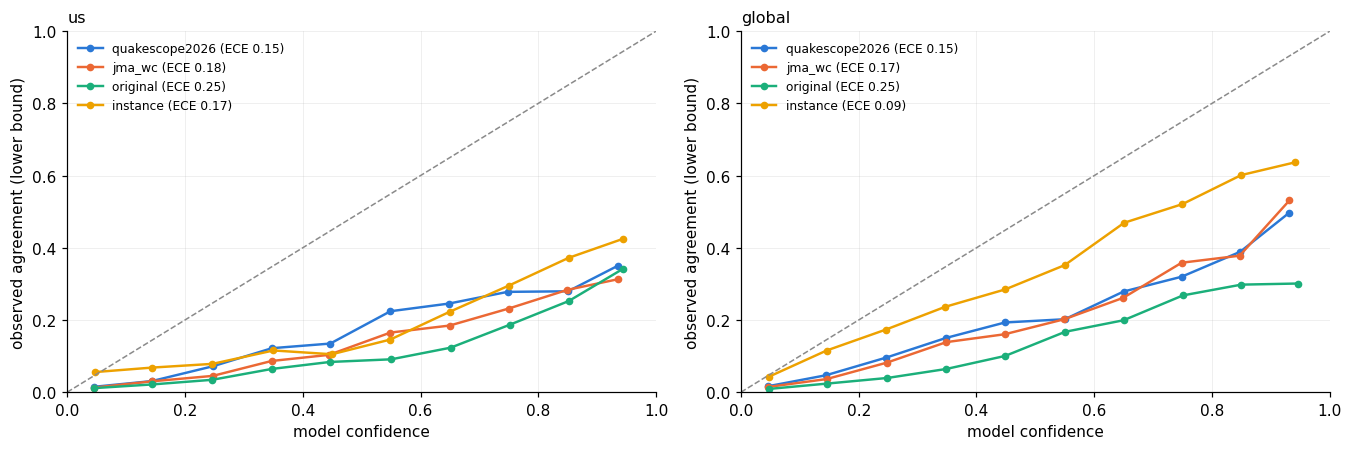

In [8]:
fig, axes = plt.subplots(1, len(studies), figsize=(6.2 * len(studies), 4.2), squeeze=False)
calib_rows = []
for ax, (study, (picks, ref)) in zip(axes[0], studies.items()):
    for name in WEIGHTS:
        conf, hit = [], []
        for (sequence, phase, sta), g in picks[picks.weights == name].groupby(["sequence", "phase", "station"]):
            rr = sorted(ref[(ref.sequence == sequence) & (ref.phase == phase)
                            & (ref.station == sta)].time.astype("int64") / 1e9)
            tt = sorted(g.time.astype("int64") / 1e9); cc = list(g.sort_values("time").conf)
            m = match_picks(rr, tt, cc, tol=DETECT_TOL)
            h = np.zeros(len(tt), dtype=bool)
            for _, j, _, _ in m["pairs"]:
                h[j] = True
            conf += cc; hit += list(h)
        tab = reliability(conf, hit, bins=10)
        if tab.empty:
            continue
        ax.plot(tab.mean_conf, tab.observed_lb, "o-", ms=4, lw=1.6, color=COLORS[name],
                label=f"{name} (ECE {ece(conf, hit):.2f})")
        calib_rows.append(dict(study=study.replace("_sequences", ""), weights=name,
                               ece_lb=ece(conf, hit), n=len(conf)))
    ax.plot([0, 1], [0, 1], color="#8a8a8a", lw=1, ls="--")
    ax.set_xlabel("model confidence"); ax.set_ylabel("observed agreement (lower bound)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(frameon=False, fontsize=8)
    ax.set_title(study.replace("_sequences", ""), loc="left", fontsize=10.5)
fig.tight_layout()
pd.DataFrame(calib_rows).to_csv(RES / "calibration_full.csv", index=False)
print(pd.DataFrame(calib_rows).round(3).to_string(index=False))

A perfectly calibrated model sits on the dashed diagonal. Everything here sits
well below it, which is expected and is not by itself a fault: the observed
agreement is a lower bound, because unmatched picks are not necessarily wrong.
What matters for model choice is that the curves differ between weight sets,
which is exactly why a threshold carried from one to another moves the
operating point.

## 5. Phase identification and duplicate picks

In [9]:
rows = []
for study, (picks, ref) in studies.items():
    for sequence in picks.sequence.unique():
        for name in WEIGHTS:
            g = picks[(picks.sequence == sequence) & (picks.weights == name) & (picks.conf >= SHARED_THR)]
            if g.empty:
                continue
            tot = {"P_n": 0, "S_n": 0, "P_matched_as_S": 0, "S_matched_as_P": 0}
            dup = {"n_matched": 0, "duplicate_picks": 0}
            for sta in g.station.unique():
                r_by = {ph: sorted(ref[(ref.sequence == sequence) & (ref.phase == ph)
                                       & (ref.station == sta)].time.astype("int64") / 1e9)
                        for ph in ("P", "S")}
                c_by = {ph: sorted(g[(g.phase == ph) & (g.station == sta)].time.astype("int64") / 1e9)
                        for ph in ("P", "S")}
                c = phase_confusion(r_by, c_by, tol=DETECT_TOL)
                for k in tot:
                    tot[k] += c[k]
                for ph in ("P", "S"):
                    m = multiplicity(r_by[ph], c_by[ph], tol=DETECT_TOL)
                    dup["n_matched"] += m["n_matched"]; dup["duplicate_picks"] += m["duplicate_picks"]
            rows.append(dict(study=study.replace("_sequences", ""), sequence=sequence, weights=name,
                             P_swapped_to_S=tot["P_matched_as_S"], P_n=tot["P_n"],
                             S_swapped_to_P=tot["S_matched_as_P"], S_n=tot["S_n"],
                             swap_rate=(tot["P_matched_as_S"] + tot["S_matched_as_P"])
                                       / max(tot["P_n"] + tot["S_n"], 1),
                             duplicate_rate=dup["duplicate_picks"] / max(dup["n_matched"], 1)))
quality = pd.DataFrame(rows)
quality.to_csv(RES / "phase_quality_full.csv", index=False)
print("Phase swaps (an analyst arrival matched by a model pick of the other phase) and duplicates")
print(quality.set_index(["sequence", "weights"]).round(3).to_string())

Phase swaps (an analyst arrival matched by a model pick of the other phase) and duplicates
                                study  P_swapped_to_S  P_n  S_swapped_to_P  S_n  swap_rate  duplicate_rate
sequence       weights                                                                                    
Ridgecrest     quakescope2026      us               3  347               3  298      0.009             0.0
               jma_wc              us               2  347               3  298      0.008             0.0
               original            us               5  347               6  298      0.017             0.0
               instance            us               1  347               0  298      0.002             0.0
San Simeon     quakescope2026      us               0   62               0   16      0.000             0.0
               jma_wc              us               0   62               0   16      0.000             0.0
               original            us               0

A swap is a different failure from a miss: it survives association and moves a
location. A duplicate is a second pick on an arrival that already matched — no
new information, and work for the associator.

## 6. The other three studies

In [10]:
for study, title in (("ridgecrest_aftershocks", "Ridgecrest, 21 events in 30 min, 5 CI stations"),
                     ("obs_offshore", "Ocean bottom: iasp91, AACSE analyst picks, Axial"),
                     ("western_reproduction", "Does the stored catalogue reproduce?")):
    print(f"\n{'=' * 78}\n{title}  [{study}]")
    d = RES / study
    if not d.exists():
        print("  not run"); continue
    for f in sorted(d.glob("*.csv")):
        t = pd.read_csv(f)
        if len(t) > 14:
            print(f"\n-- {f.stem} ({len(t)} rows, head)"); print(t.head(8).round(3).to_string(index=False))
        else:
            print(f"\n-- {f.stem}"); print(t.round(3).to_string(index=False))


Ridgecrest, 21 events in 30 min, 5 CI stations  [ridgecrest_aftershocks]

-- per_station
station  analyst_S  quakescope2026  jma_wc  original  instance
    CLC         20            0.85    0.85      0.85      0.60
   WCS2         18            0.83    0.83      0.89      0.83
    MPM         18            0.72    0.78      0.78      0.72
    WBS         18            0.72    0.78      0.89      0.72
   JRC2         15            0.87    0.87      0.93      0.80
    WOR         19            0.74    0.79      0.84      0.79
    TEH         18            0.89    0.83      0.89      0.67
    LRL         18            0.72    0.72      0.89      0.72

-- recall_at_threshold
       weights phase  analyst  matched  recall   MAE   bias  extra
quakescope2026     P      125      116   0.928 0.034 -0.012    414
quakescope2026     S      144      114   0.792 0.045 -0.012    321
        jma_wc     P      125      117   0.936 0.030 -0.012    402
        jma_wc     S      144      116   0.806 0.05

## 7. What to report, if you are writing this up

The set below is what we would ask of any picker comparison on real network
data. It is the union of what Münchmeyer et al. (2022) report on labelled
datasets and what an operator bulletin still permits.

| report | because |
|---|---|
| recall **and** the number of picks emitted | recall alone is gameable by lowering the threshold |
| recall at a matched pick budget | the only comparison that survives a change of threshold |
| each model's own best threshold | what a tuned deployment would actually run |
| `precision_lb`, `f1_lb`, named as bounds | comparable between models, not with the literature |
| MAE and RMSE | one insensitive to outliers, one not |
| MedianAE and median bias | robust scatter, and systematic earliness or lateness |
| gross-error rate beyond the detection tolerance | the outlier statistic the matching tolerance does not define away |
| a reliability curve and ECE | tells you whether your threshold transfers between models |
| phase swap rate | a failure that survives association |
| duplicate rate | cost to the associator, invisible in recall |
| the reference count per row | recall on 16 arrivals is not recall on 701 |
| the matching tolerance, and the residual tolerance separately | otherwise the outlier rate is undefined |

And two things to state in words, not numbers: **where the reference came from**
(who picked it, for what purpose, and what they skipped), and **whether the
model saw any of it in training**. Both change the interpretation more than any
metric on the list.

## 8. Run this on your own picks

Every number on this page comes out of one script, and it does not care whose
picks they are:

```
python scripts/score_picks.py --reference arrivals.csv --picks mypicks.csv --out scores/
```

Two input files. **`--reference`** is the arrivals you are scoring against, one
row each:

| station | phase | time |
|---|---|---|
| NZ.KHZ | P | 2016-11-13T11:12:58.400 |
| NZ.KHZ | S | 2016-11-13T11:13:04.100 |

**`--picks`** is what the model emitted, with its confidence:

| station | phase | time | conf |
|---|---|---|---|
| NZ.KHZ | P | 2016-11-13T11:12:58.512 | 0.83 |
| NZ.KHZ | S | 2016-11-13T11:13:04.061 | 0.41 |

Run the model **once at a low confidence floor** and keep every pick. Each
threshold in section 2 is then a filter over this one file instead of another
pass over the waveforms, which is what makes the sweep affordable.

Two optional columns: `dataset`, to score several sequences, regions or
experiments in one run, and, in the picks file, `model`, to compare several
models against the same reference. Each defaults to a single unnamed group. The
script also takes the names you probably already use - `sequence`, `event`,
`region` for `dataset`; `weights`, `picker`, `method` for `model`;
`confidence`, `probability`, `peak_value` for `conf`; `pick_time`,
`arrival_time` for `time` - so the files the QuakeScope notebooks export, and
most SeisBench output, work unchanged. Parquet is read as readily as CSV.

| option | default | what it does |
|---|---|---|
| `--threshold` | 0.3 | the shared threshold to report at |
| `--tol` | 0.5 s | an arrival counts as recovered within this |
| `--residual-tol` | 2.0 s | residuals matched this wide, so the distribution in section 3 is not truncated by `--tol` |
| `--exhaustive` | off | your reference marks *every* arrival, so precision and F1 are exact and the `_lb` suffix is dropped |
| `--demo` | - | synthetic picks with known properties, so you can see the output before you have data |

It prints the four tables below and writes them as `detection.csv`,
`timing.csv`, `calibration.csv`, `phase_quality.csv`, plus `sweep.csv`, the
full threshold curve all of them are read off.

To use it outside this repository, copy two files next to each other:
[`sb_catalog/src/benchmark_metrics.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/sb_catalog/src/benchmark_metrics.py)
and [`scripts/score_picks.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/scripts/score_picks.py). They import
nothing but `numpy` and `pandas`.

### See it work first

`--demo` builds 300 synthetic arrivals on one station and three models whose
properties are known: `sharp` is accurate, `late` carries a 0.15 s systematic
delay, and `liberal` finds more arrivals but emits twice the picks. Read the
output against those three facts.

In [11]:
import subprocess
import tempfile

SCORER = ["python", "../scripts/score_picks.py"]
demo_out = tempfile.mkdtemp()
print(subprocess.run(SCORER + ["--demo", "--out", demo_out],
                     capture_output=True, text=True).stdout)

demo: 300 synthetic arrivals on one station, three models - `sharp` accurate, `late` 0.15 s delayed, `liberal` finds more but emits 2x the picks

300 reference arrivals on 1 station, 1,999 picks on 1 station, 1 station in both

DETECTION  (recall is exact; precision and f1 are LOWER BOUNDS - see the docstring at the top of this script)
dataset phase   model  n_reference  emitted  recall  precision_lb  f1_lb  recall_at_budget  budget  best_threshold  recall_at_best
   demo     P    late          150      145   0.700         0.724  0.712             0.614     102            0.44           0.653
   demo     P liberal          150      310   0.900         0.435  0.587             0.619     102            0.54           0.767
   demo     P   sharp          150      143   0.713         0.748  0.730             0.618     102            0.44           0.693
   demo     S    late          150      158   0.720         0.684  0.701             0.651     110            0.48           0.693
   demo

Three things to take from that, because each one is a trap in a real comparison:

- **`late` is not worse at detection.** Its recall matches `sharp` to a point
  or two, and the 0.15 s delay shows up only in `bias` and in `within_0.1`,
  which collapses from 1.00 to 0.08. A detection-only table would have called
  the two models equivalent.
- **`liberal` wins on recall and loses on `precision_lb`,** because it emits
  twice the picks. At `recall_at_budget`, where all three are read at the same
  number of emitted picks, the three agree within a few points. That is the
  whole argument of section 2, on data where the answer is known.
- **`sharp` has the lowest ECE** and still shows swaps and duplicates. Those
  come from the synthetic noise picks landing near a real arrival, which is
  also how they arise on real data.

### Does it reproduce this page?

The script is the same code path as the cells above, so it should return the
same numbers. Worth checking rather than asserting: the cell below runs it on
both sequence studies and differences the result against the `detection`,
`timing` and `quality` tables computed earlier in this notebook.

In [12]:
checks = []
for study, (picks, ref) in studies.items():
    out = tempfile.mkdtemp()
    r = subprocess.run(SCORER + ["--reference", str(RES / study / "reference_picks.csv"),
                                 "--picks", str(RES / study / "model_picks.csv"),
                                 "--out", out, "--threshold", str(SHARED_THR),
                                 "--tol", str(DETECT_TOL), "--residual-tol", str(RESIDUAL_TOL)],
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stderr[-800:]); continue
    tag = study.replace("_sequences", "")
    KEY = {"dataset": "sequence", "model": "weights"}
    # Both sides are read back from CSV, so the CSV writer's 16 significant
    # digits cannot show up as a spurious 1e-16 disagreement.
    for fname, published, pairs in (
            ("detection.csv", "detection_full.csv",
             [("recall", "recall_at_03"), ("precision_lb", "precision_lb_at_03"),
              ("f1_lb", "f1_lb_at_03"), ("emitted", "emitted_at_03"),
              ("recall_at_budget", "recall_at_budget"), ("budget", "budget"),
              ("best_threshold", "best_thr"), ("recall_at_best", "recall_at_best")]),
            ("timing.csv", "timing_full.csv",
             [("mae", "mae"), ("rmse", "rmse"), ("medae", "medae"), ("bias", "bias"),
              ("std", "std"), ("gross_error_rate", "gross_error_rate"),
              ("within_0.1", "within_0.1"), ("n", "n")]),
            ("phase_quality.csv", "phase_quality_full.csv",
             [("swap_rate", "swap_rate"), ("duplicate_rate", "duplicate_rate")])):
        mine = pd.read_csv(RES / published)
        got = pd.read_csv(Path(out) / fname).rename(columns=KEY)
        on = [c for c in ("sequence", "phase", "weights") if c in got.columns]
        j = mine[mine.study == tag].merge(got, on=on, suffixes=("_nb", "_cli"))
        for a, b in pairs:
            ca = a + ("_cli" if a + "_cli" in j.columns else "")
            cb = b + ("_nb" if b + "_nb" in j.columns else "")
            checks.append({"study": tag, "table": fname, "metric": b, "rows": len(j),
                           "max_abs_diff": (j[ca].astype(float) - j[cb].astype(float)).abs().max()})

chk = pd.DataFrame(checks)
worst = chk.max_abs_diff.max()
print(f"{len(chk)} metrics compared on {chk.rows.sum()} row-pairs, "
      f"{chk.study.nunique()} studies, {chk.table.nunique()} tables")
print(f"largest disagreement between this page and scripts/score_picks.py: {worst:g}")
print("bit-identical" if worst == 0 else "DIFFERS - the script and the page are not the same code path")
chk.groupby(["study", "table"]).agg(metrics=("metric", "count"), rows=("rows", "max"),
                                    max_abs_diff=("max_abs_diff", "max"))

36 metrics compared on 952 row-pairs, 2 studies, 3 tables
largest disagreement between this page and scripts/score_picks.py: 0
bit-identical


metrics  rows  max_abs_diff
study  table                                         
global detection.csv            8    24           0.0
       phase_quality.csv        2    12           0.0
       timing.csv               8    24           0.0
us     detection.csv            8    32           0.0
       phase_quality.csv        2    16           0.0
       timing.csv               8    32           0.0

Bit-identical. So the command in this section, run on your own two CSV files,
gives you the same quantities this page reports for the four PhaseNet weight
sets, computed by the same code, with the same `_lb` naming wherever the
reference is not exhaustive.

One caveat on that zero: both sides of the comparison are read back from CSV
on purpose. `pandas.to_csv` writes 16 significant digits, so `1/3` does not
round-trip, and comparing a CSV against a float still in memory shows a
harmless disagreement around 1e-16. It is a property of the file format, not
of the metric, and it is the reason the cell above reads both sides from disk.

Two mistakes the script refuses to let you publish. Station names that differ
between the two files would otherwise report a working picker as recall 0, so
it stops and shows you a spelling from each side. Disjoint time windows, the
usual sign of a time-zone or epoch-unit error, are also fatal. A partial
station overlap is only a warning, because scoring a subset of a network is a
reasonable thing to do.

If you need a metric that is not here, add it to
[`benchmark_metrics.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/sb_catalog/src/benchmark_metrics.py)
with a test in
[`test_benchmark_metrics.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/tests/test_benchmark_metrics.py)
that pins it on a case you worked out by hand. Every function there has one,
which is what makes the check above worth reading. The script itself is pinned
by [`tests/test_score_picks_cli.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/tests/test_score_picks_cli.py),
which checks its numbers against the module end to end, that both fatal
mismatches above really are fatal, and that two runs under different hash seeds
write byte-identical files.